In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r'C:\Users\Gouthami\Documents\DSML\Customer_churn_prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
import seaborn as sns

In [7]:
cat_col = []
num_col = []
for col in data.columns:
    if (data[col].dtype == 'str'):
        cat_col.append(col)
    else:
        num_col.append(col)

In [8]:
cat_col.remove('Churn')
cat_col.remove('customerID')

In [9]:
data.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [10]:
conv_col = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [11]:
conv_col.isnull().sum()

np.int64(11)

In [12]:
data[conv_col.isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [13]:
data['TotalCharges'] = data['TotalCharges'].str.strip()

In [14]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [15]:
data['TotalCharges'].dtype

dtype('float64')

In [16]:
cat_col.remove('TotalCharges')
num_col.append('TotalCharges')

In [17]:
print(len(cat_col))
print(len(num_col))

15
4


In [18]:
data['TotalCharges'].isnull().sum()

np.int64(11)

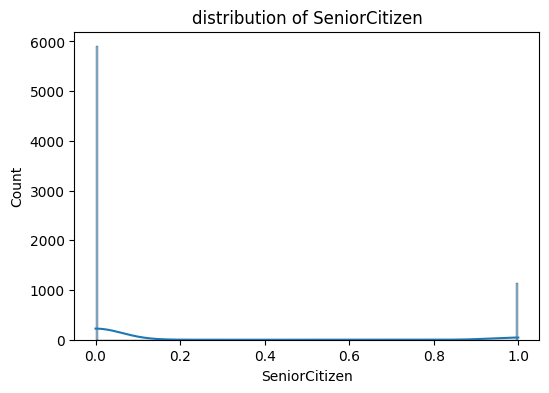

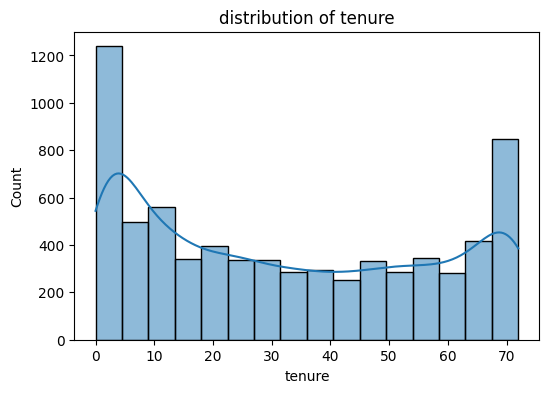

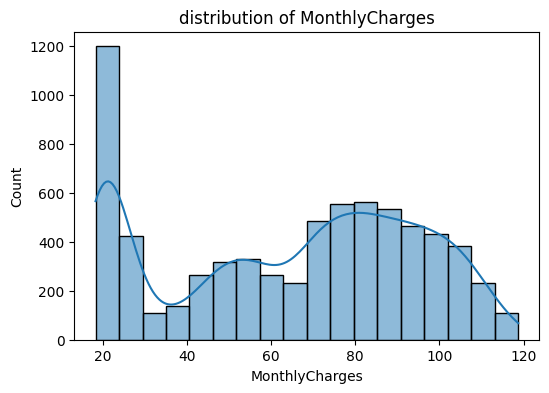

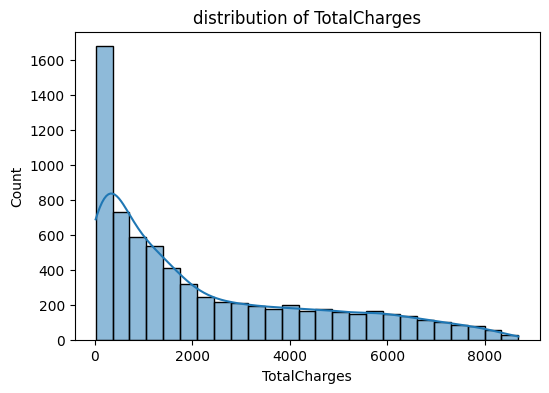

In [19]:
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(data=data, x=col, kde=True)
    plt.title(f"distribution of {col}")
    plt.show()


In [20]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
num_col.remove('SeniorCitizen')
cat_col.append('SeniorCitizen')

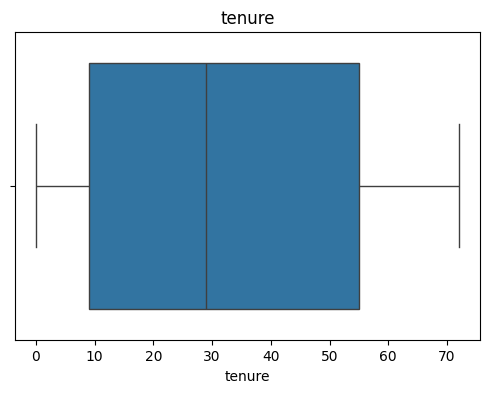

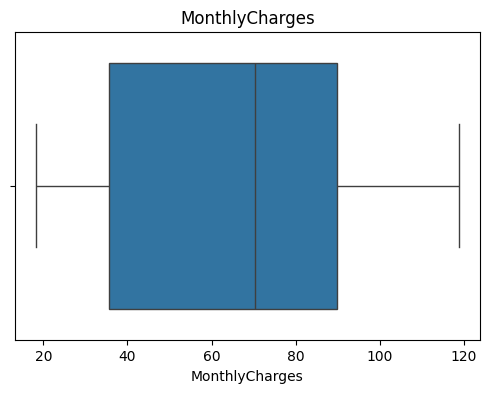

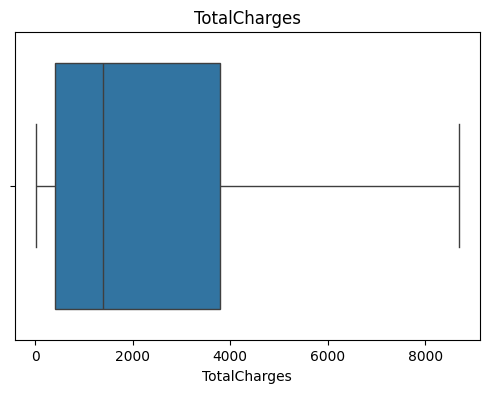

In [22]:
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=data, x=col)
    plt.title(col)
    plt.show()

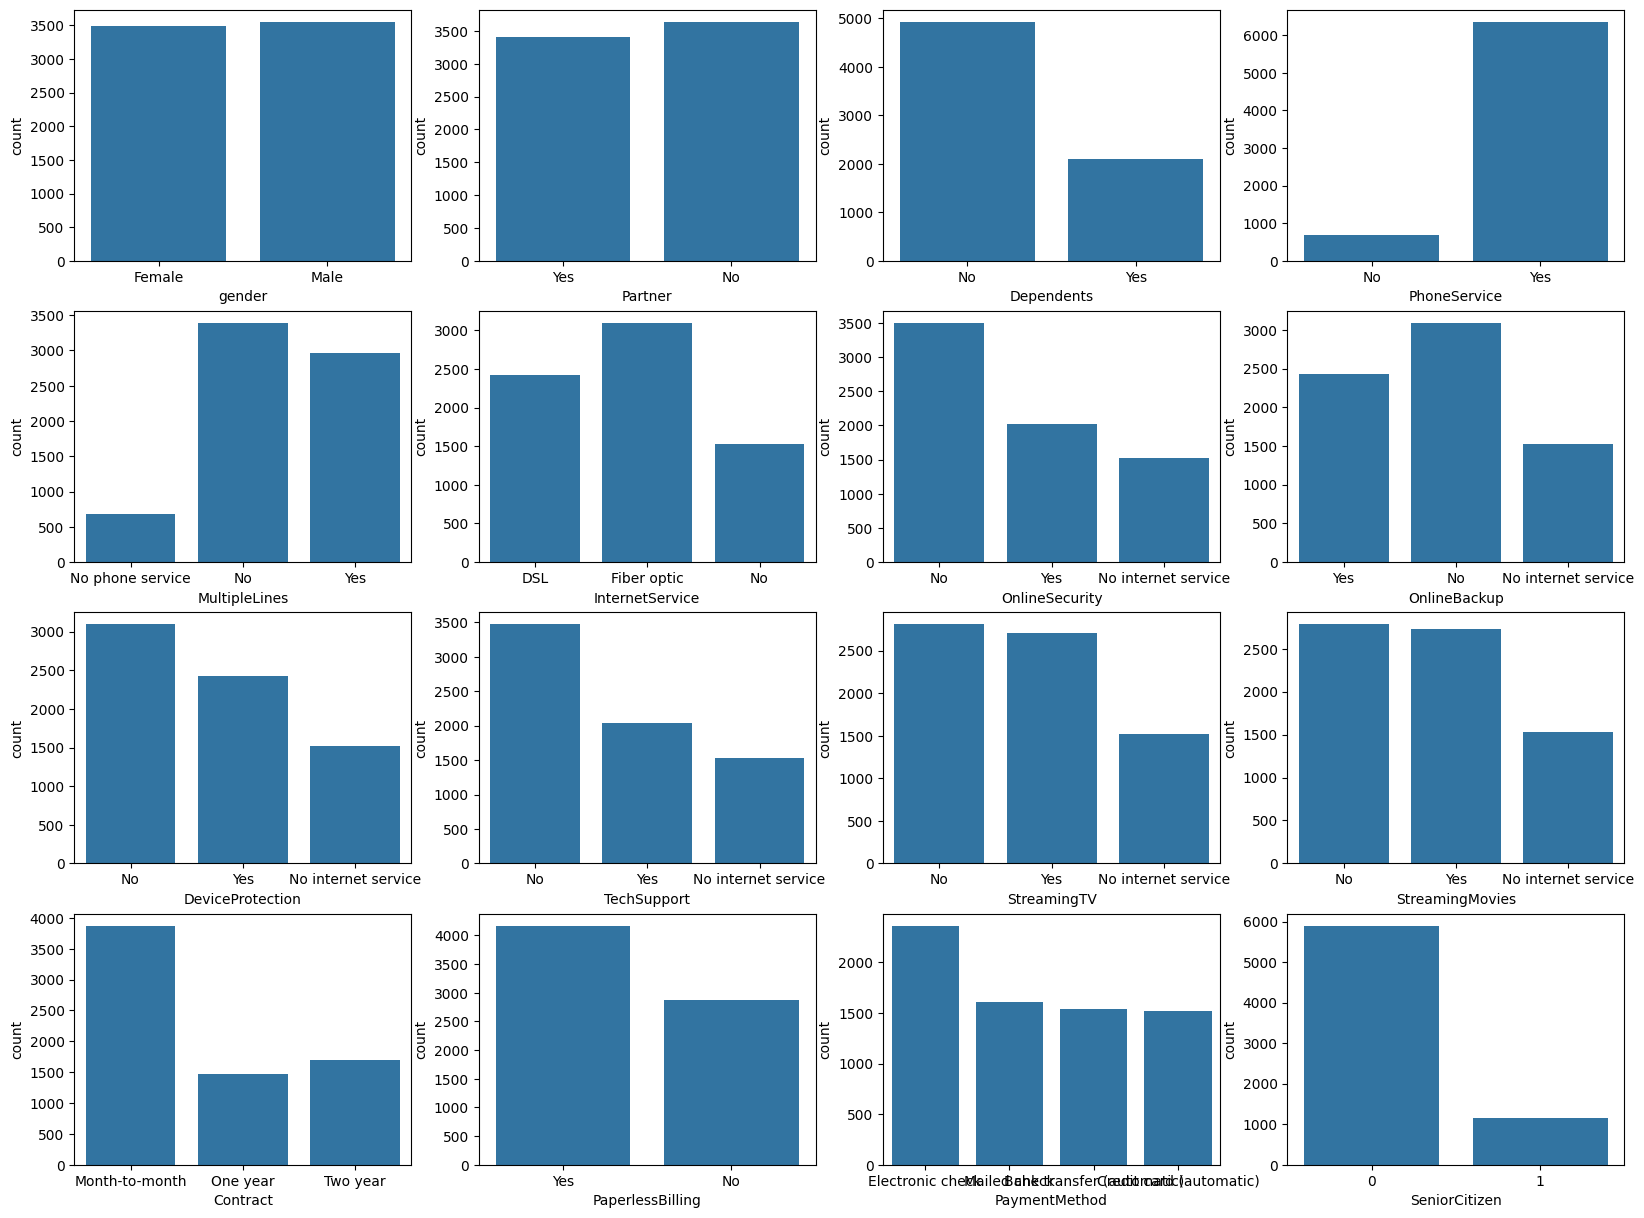

In [23]:
fig, axes = plt.subplots(4,4, figsize = (20,15))
axes = axes.flatten()  
for i, col in enumerate(cat_col):
    sns.countplot(data=data, x=col, ax=axes[i])
plt.show()

In [24]:
for col in cat_col:
    print(data[col].value_counts(normalize=True))
    print("\n")

gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64


Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64


Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64


PhoneService
Yes    0.903166
No     0.096834
Name: proportion, dtype: float64


MultipleLines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64


InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64


OnlineSecurity
No                     0.496663
Yes                    0.286668
No internet service    0.216669
Name: proportion, dtype: float64


OnlineBackup
No                     0.438450
Yes                    0.344881
No internet service    0.216669
Name: proportion, dtype: float64


DeviceProtection
No                     0.439443
Yes                    0.343888
No internet service    0.216669
Name: proportion, dtype: 

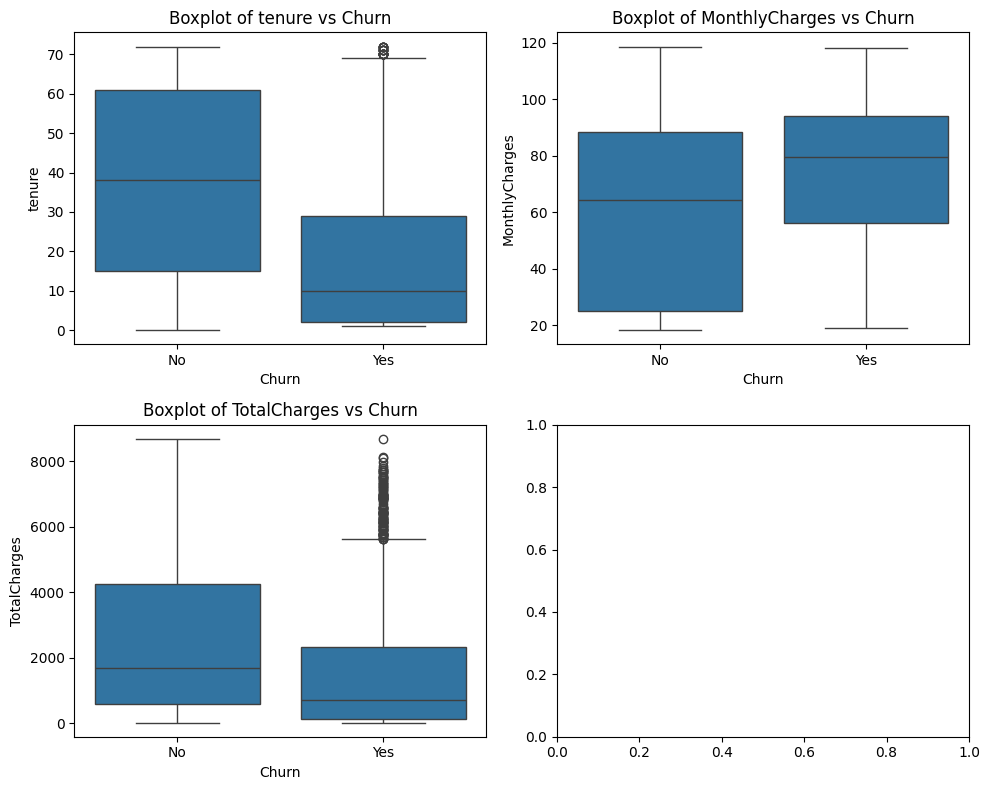

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()
for i, col in enumerate(num_col):
    sns.boxplot(data=data, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} vs Churn")
plt.tight_layout()
plt.show()

In [26]:
data['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

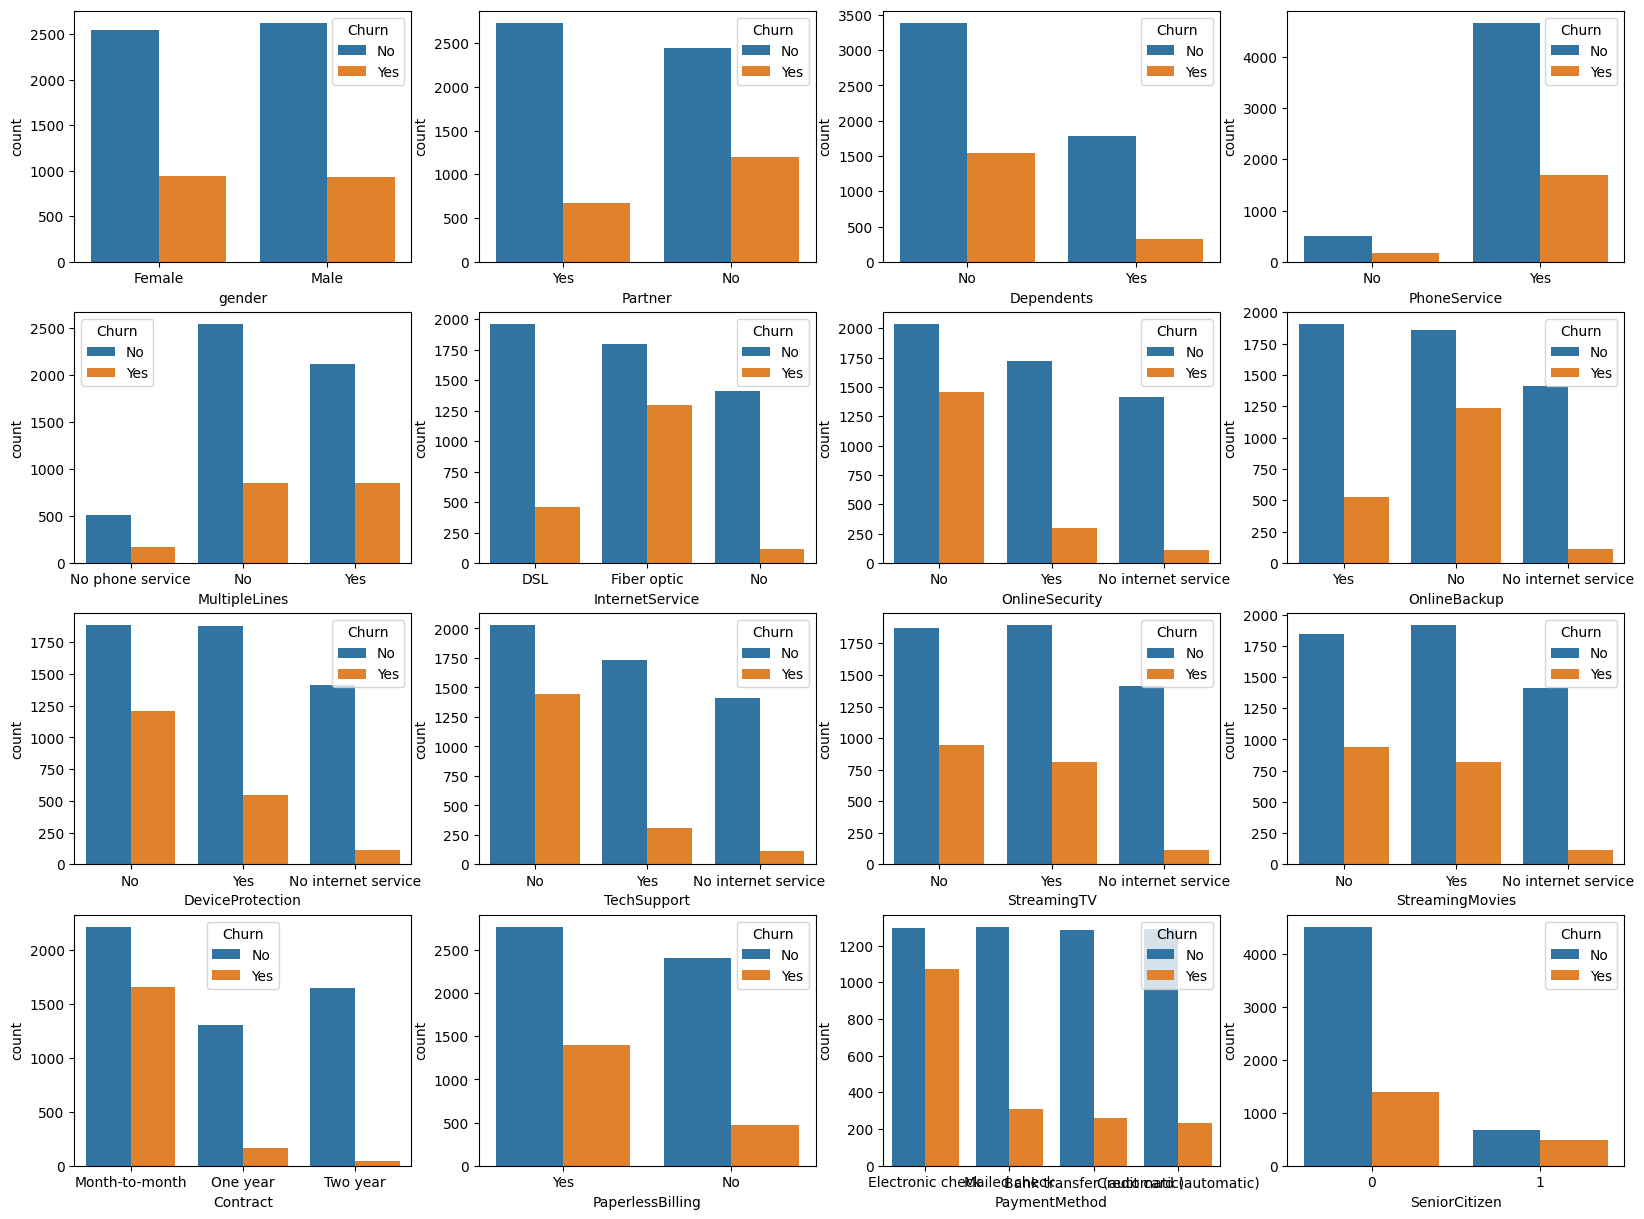

In [27]:
fig, axes = plt.subplots(4,4, figsize = (20,15))
axes = axes.flatten()  
for i, col in enumerate(cat_col):
    sns.countplot(data=data, x=col, hue='Churn', ax=axes[i])
plt.show()

In [28]:
for col in cat_col:
    print(pd.crosstab(data[col], data['Churn'], normalize='index'))
    print("\n")

Churn         No       Yes
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603


Churn          No       Yes
Partner                    
No       0.670420  0.329580
Yes      0.803351  0.196649


Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502


Churn               No       Yes
PhoneService                    
No            0.750733  0.249267
Yes           0.732904  0.267096


Churn                   No       Yes
MultipleLines                       
No                0.749558  0.250442
No phone service  0.750733  0.249267
Yes               0.713901  0.286099


Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050


Churn                      No       Yes
OnlineSecurity                         
No                   0.582333  0.417667
No internet service  0.9259

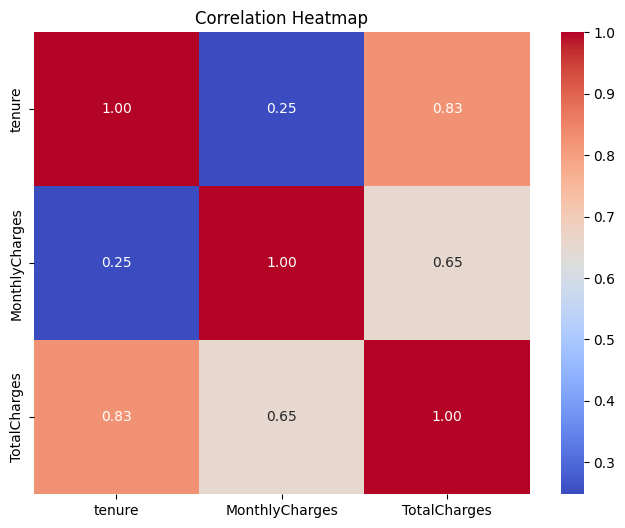

In [29]:
# correlation matrix
corr_matrix = data[num_col].corr()

# plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()


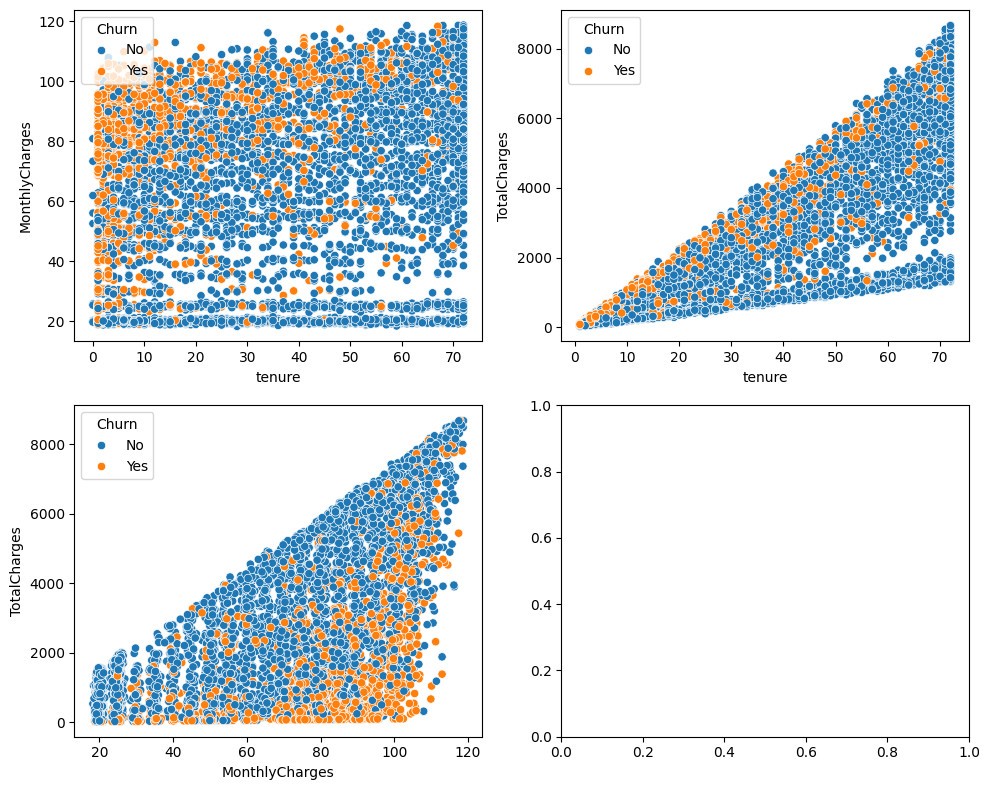

In [30]:
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
cnt = -1
for i in range(len(num_col)):
    for j in range(i+1, len(num_col)):
        cnt+=1
        sns.scatterplot(data=data, x = num_col[i], y = num_col[j], hue='Churn', ax=axes[cnt])
plt.tight_layout()        
plt.show()        